In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_gaus, fit_gaus_minuit, fit_gaus_minuit_grad

In [2]:
ROWS = 128
COLS = 128
N_SCAN = 100
NOISE_FRAC = 0.10
SEED = 1991
N_REPEATS = 5
N_THREADS = 4

In [3]:
def generate_3d_data(rows, cols, n_scan, noise_frac, seed):
    """
    Generate a synthetic detector image stack where each pixel has a
    Gaussian response curve with per-pixel variation in A, mu, sigma.

    Returns x (n_scan,), y (rows, cols, n_scan), y_err (rows, cols, n_scan),
    and the ground-truth parameter arrays.
    """
    rng = np.random.default_rng(seed)

    # Per-pixel true params each of shape: [rows, cols, 1]
    A_true = rng.uniform(200, 1000, size=(rows, cols))
    mu_true = rng.uniform(20, 80, size=(rows, cols))
    sig_true = rng.uniform(3, 12, size=(rows, cols))
    
    # One common binned energy array
    x = np.linspace(0, 100, n_scan) # shape [1, 1, nscan]

    # Build ground truth signals per-pixel
    exponent = -0.5 * ((x[None, None, :] - mu_true[:, :, None]) / sig_true[:,:, None])**2 # shape [rows, cols, nscan]
    y_clean = A_true[:, :, None] * np.exp(exponent)

    # Perturb with noise
    noise_sigma = noise_frac * A_true[:, :, None] * np.ones_like(y_clean) # shape [rows, cols, nscan]
    noise = rng.normal(0, noise_sigma)
    y = y_clean + noise

    y_err = noise_sigma.copy()

    return x, y, y_err, A_true, mu_true, sig_true    

In [4]:
def bench(fn, n_repeats=N_REPEATS):
    times = []
    result = None
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        result = fn()
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return result, np.array(times)

Generating synthetic data: 128x128 pixels, 100 scan points, noise_frac=0.1

[lmfit (LM)            ]  time= 550.31 ms  chi2/ndf=0.9937  med|dA|=12.512  med|dMu|=0.1865  med|dSig|=0.1901
[Minuit2 (analytic)    ]  time= 658.64 ms  chi2/ndf=0.9937  med|dA|=12.508  med|dMu|=0.1864  med|dSig|=0.1901
  lmfit (LM)              n_threads= 1  -> 1610.24 ms
  lmfit (LM)              n_threads= 2  -> 823.07 ms
  lmfit (LM)              n_threads= 4  -> 467.90 ms
  lmfit (LM)              n_threads= 8  -> 446.50 ms
  Minuit2 (analytic)      n_threads= 1  -> 2336.25 ms
  Minuit2 (analytic)      n_threads= 2  -> 1204.95 ms
  Minuit2 (analytic)      n_threads= 4  -> 664.75 ms
  Minuit2 (analytic)      n_threads= 8  -> 732.99 ms


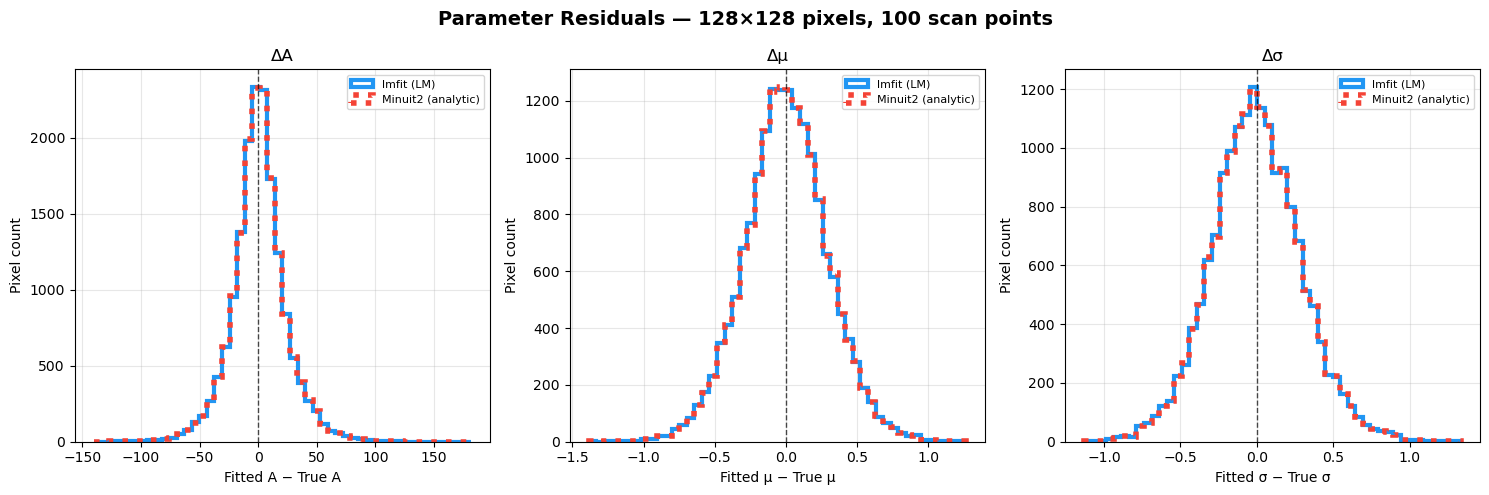

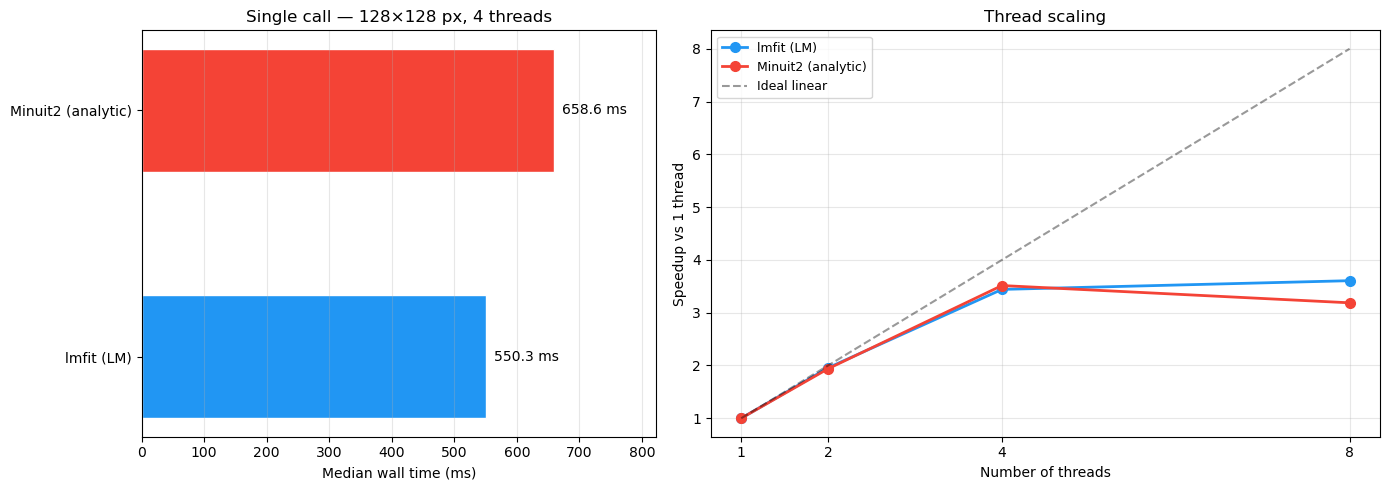

In [8]:
print(f"Generating synthetic data: {ROWS}x{COLS} pixels, "
      f"{N_SCAN} scan points, noise_frac={NOISE_FRAC}\n")

x, y, yerr, true_A, true_mu, true_sig = generate_3d_data(
    ROWS, COLS, N_SCAN, NOISE_FRAC, SEED
)

# ---- Run all three fitters ----
methods = {}

res, times = bench(lambda: fit_gaus(x, y, yerr, n_threads=N_THREADS))
methods["lmfit (LM)"] = {"par": res["par"], "chi2": res["chi2"], "times": times}

# res, times = bench(lambda: fit_gaus_minuit(x, y, y_err=yerr, n_threads=N_THREADS))
# methods["Minuit2 (FD)"] = {"par": res["par"], "chi2": res["chi2"], "times": times}

res, times = bench(lambda: fit_gaus_minuit_grad(x, y, y_err=yerr, n_threads=N_THREADS))
methods["Minuit2 (analytic)"] = {"par": res["par"], "chi2": res["chi2"], "times": times}

# ---- Print summary ----
ndf = N_SCAN - 3
for name, m in methods.items():
    par = m["par"]
    med_t = np.median(m["times"]) * 1e3
    med_chi2 = np.median(m["chi2"] / ndf)
    dA  = np.median(np.abs(par[:,:,0] - true_A))
    dMu = np.median(np.abs(par[:,:,1] - true_mu))
    dSig= np.median(np.abs(par[:,:,2] - true_sig))
    print(f"[{name:22s}]  time={med_t:7.2f} ms  "
          f"chi2/ndf={med_chi2:.4f}  "
          f"med|dA|={dA:.3f}  med|dMu|={dMu:.4f}  med|dSig|={dSig:.4f}")

# ---- Thread scaling ----
thread_counts = [1, 2, 4, 8]
thread_times = {}
for label, fn_factory in [
    ("lmfit (LM)",          lambda nt: lambda: fit_gaus(x, y, yerr, n_threads=nt)),
    # ("Minuit2 (FD)",        lambda nt: lambda: fit_gaus_minuit(x, y, y_err=yerr, n_threads=nt)),
    ("Minuit2 (analytic)",  lambda nt: lambda: fit_gaus_minuit_grad(x, y, y_err=yerr, n_threads=nt)),
]:
    thread_times[label] = []
    for nt in thread_counts:
        _, times = bench(fn_factory(nt), n_repeats=N_REPEATS)
        thread_times[label].append(np.median(times) * 1e3)
        print(f"  {label:22s}  n_threads={nt:2d}  -> {thread_times[label][-1]:.2f} ms")

# =========================================
# FIGURE 1: Residual histograms (accuracy)
# =========================================
# colors = {"lmfit (LM)": "#2196F3", "Minuit2 (FD)": "#FF9800", "Minuit2 (analytic)": "#4CAF50"}
colors = {"lmfit (LM)": "#2196F3", "Minuit2 (analytic)": "#F44336"}
styles = {
    "lmfit (LM)":          {"linewidth": 3.0, "linestyle": "-"},
    # "Minuit2 (FD)":        {"linewidth": 2.0, "linestyle": "--"},
    "Minuit2 (analytic)":  {"linewidth": 4.0, "linestyle": ":"},
}
param_names  = ["A", "μ", "σ"]
param_truths = [true_A, true_mu, true_sig]

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(f"Parameter Residuals — {ROWS}×{COLS} pixels, {N_SCAN} scan points",
              fontsize=14, fontweight="bold")

for col, (pname, truth) in enumerate(zip(param_names, param_truths)):
    ax = axes1[col]
    for mname, m in methods.items():
        residual = (m["par"][:, :, col] - truth).ravel()  # flattens shape to (ROWS*COLS,)
        ax.hist(residual, bins=50, histtype="step", label=mname,
                color=colors[mname], 
                linewidth=styles[mname]["linewidth"],
                linestyle=styles[mname]["linestyle"])
    ax.axvline(0, color="k", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel(f"Fitted {pname} − True {pname}")
    ax.set_ylabel("Pixel count")
    ax.set_title(f"Δ{pname}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig1.tight_layout()
# fig1.savefig("fig1_residual_histograms.png", dpi=150, bbox_inches="tight")
# print("\nSaved fig1_residual_histograms.png")

# ====================================================
# FIGURE 2: Performance — bar chart + thread scaling
# ====================================================
fig2 = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 2, figure=fig2, width_ratios=[1, 1.3])

# -- Left: bar chart of median times at N_THREADS --
ax2a = fig2.add_subplot(gs[0])
names = list(methods.keys())
medians = [np.median(methods[n]["times"]) * 1e3 for n in names]
bars = ax2a.barh(names, medians, color=[colors[n] for n in names],
                 edgecolor="white", height=0.5)
ax2a.set_xlabel("Median wall time (ms)")
ax2a.set_title(f"Single call — {ROWS}×{COLS} px, {N_THREADS} threads")
for bar, val in zip(bars, medians):
    ax2a.text(bar.get_width() + max(medians)*0.02, bar.get_y() + bar.get_height()/2,
              f"{val:.1f} ms", va="center", fontsize=10)
ax2a.grid(axis="x", alpha=0.3)
ax2a.set_xlim(0, max(medians) * 1.25)

# -- Right: thread scaling --
ax2b = fig2.add_subplot(gs[1])

method_list = list(methods.keys())
for mname in method_list:
    tt = thread_times[mname]
    speedup = [tt[0] / t for t in tt]
    ax2b.plot(thread_counts, speedup, "o-", label=mname,
              color=colors[mname], linewidth=2, markersize=7)
ax2b.plot(thread_counts, thread_counts, "k--", alpha=0.4, label="Ideal linear")
ax2b.set_xlabel("Number of threads")
ax2b.set_ylabel("Speedup vs 1 thread")
ax2b.set_title("Thread scaling")
ax2b.set_xticks(thread_counts)
ax2b.legend(fontsize=9)
ax2b.grid(alpha=0.3)

fig2.tight_layout()
# fig2.savefig("fig2_performance.png", dpi=150, bbox_inches="tight")
# print("Saved fig2_performance.png")

plt.show()